In [1]:
# Hand Gesture Recognition using CNN

# ---------------- IMPORT LIBRARIES ----------------

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical

C:\Users\hally\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\hally\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\hally\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\hally\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\hal

In [2]:
# ---------------- DATASET PATH ----------------

dataset_path = r"C:\Users\hally\Downloads\Prodigy_internship_tasks\leapGestRecog"

# image settings
IMG_SIZE = 64

data = []
labels = []

gesture_names = {}

In [3]:
# ---------------- LOAD DATASET ----------------

print("loading images...")

gesture_map = {}

current_label = 0

# create gesture label mapping only once
for person_folder in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person_folder)

    if not os.path.isdir(person_path):
        continue

    for gesture_folder in os.listdir(person_path):

        if gesture_folder not in gesture_map:

            gesture_map[gesture_folder] = current_label

            current_label += 1

gesture_names = {
    v:k for k,v in gesture_map.items()
}

# load images
for person_folder in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person_folder)

    if not os.path.isdir(person_path):
        continue

    for gesture_folder in os.listdir(person_path):

        gesture_path = os.path.join(
            person_path,
            gesture_folder
        )

        if not os.path.isdir(gesture_path):
            continue

        label = gesture_map[gesture_folder]

        count = 0

        for img_name in os.listdir(gesture_path):

            try:

                img_path = os.path.join(
                    gesture_path,
                    img_name
                )

                img = cv2.imread(img_path)

                gray = cv2.cvtColor(
                    img,
                    cv2.COLOR_BGR2GRAY
                )

                resized = cv2.resize(
                    gray,
                    (IMG_SIZE, IMG_SIZE)
                )

                resized = resized / 255.0

                data.append(resized)

                labels.append(label)

                count += 1

                # limit images per class
                if count >= 300:
                    break

            except:
                pass

print("dataset loaded")

loading images...
dataset loaded


In [4]:
# ---------------- CONVERT TO NUMPY ----------------

X = np.array(data)

y = np.array(labels)

# reshape for CNN
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# categorical labels
y = to_categorical(y)

print("dataset shape:", X.shape)

dataset shape: (20000, 64, 64, 1)


In [5]:
# ---------------- TRAIN TEST SPLIT ----------------

xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
# ---------------- BUILD CNN MODEL ----------------

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(IMG_SIZE, IMG_SIZE, 1)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(10, activation='softmax'))

C:\Users\hally\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [7]:
# ---------------- COMPILE MODEL ----------------

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# ---------------- TRAIN MODEL ----------------

print("training model...")

history = model.fit(
    xtrain,
    ytrain,
    epochs=5,
    validation_data=(xtest, ytest),
    batch_size=32
)

print("training completed")

training model...
Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 104ms/step - accuracy: 0.7346 - loss: 0.7911 - val_accuracy: 0.9983 - val_loss: 0.0112
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.9911 - loss: 0.0283 - val_accuracy: 0.9998 - val_loss: 0.0023
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 93ms/step - accuracy: 0.9951 - loss: 0.0173 - val_accuracy: 0.9987 - val_loss: 0.0040
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 77ms/step - accuracy: 0.9981 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 5.7996e-04
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.9987 - loss: 0.0061 - val_accuracy: 1.0000 - val_loss: 7.6670e-04
training completed


In [9]:
# ---------------- EVALUATION ----------------

loss, accuracy = model.evaluate(
    xtest,
    ytest
)

print("\nAccuracy:", accuracy * 100)

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 1.0000 - loss: 7.3428e-04

Accuracy: 100.0


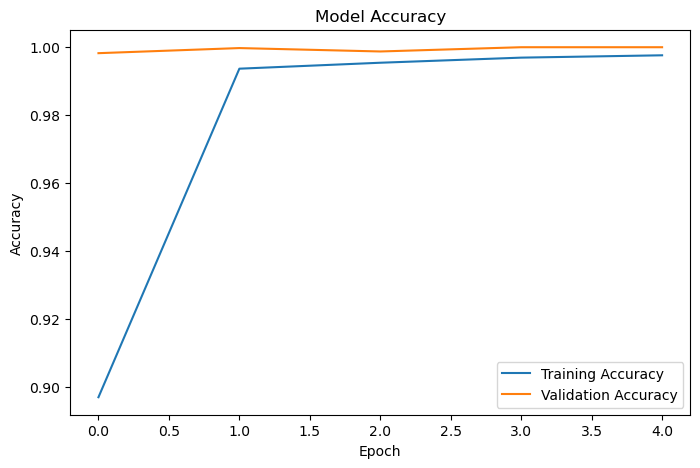

In [10]:
# ---------------- ACCURACY GRAPH ----------------

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


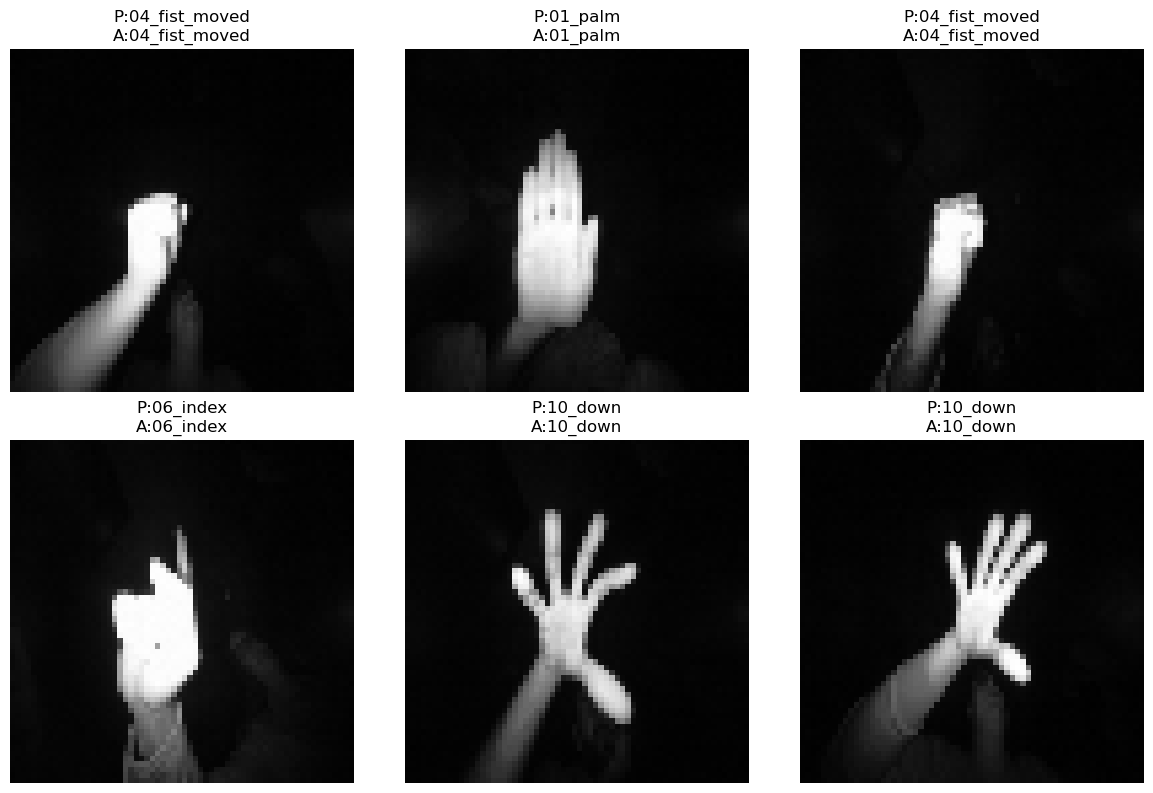

In [11]:
# ---------------- SAMPLE PREDICTIONS ----------------

predictions = model.predict(xtest)

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    img = xtest[i].reshape(
        IMG_SIZE,
        IMG_SIZE
    )

    predicted_label = np.argmax(predictions[i])

    actual_label = np.argmax(ytest[i])

    plt.imshow(img, cmap='gray')

    plt.title(
        f"P:{gesture_names[predicted_label]}\n"
        f"A:{gesture_names[actual_label]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()